In [519]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [520]:
df = pd.read_csv(r"C:\Users\SHIVA KUMAR\Desktop\Assigmnt\Random Forest\Company_Data.csv")
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [521]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


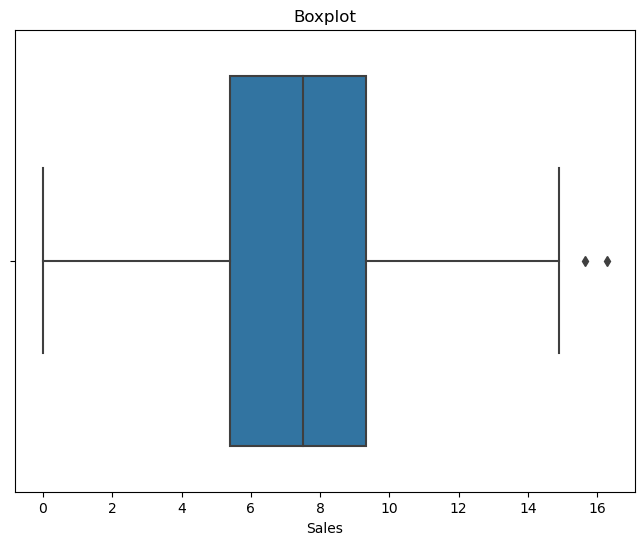

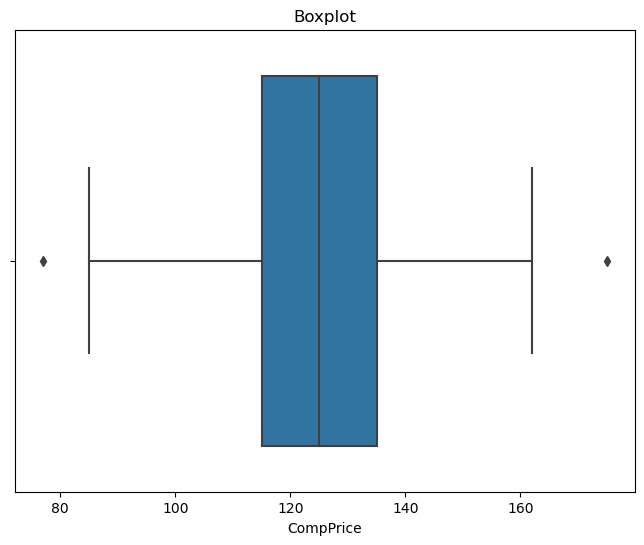

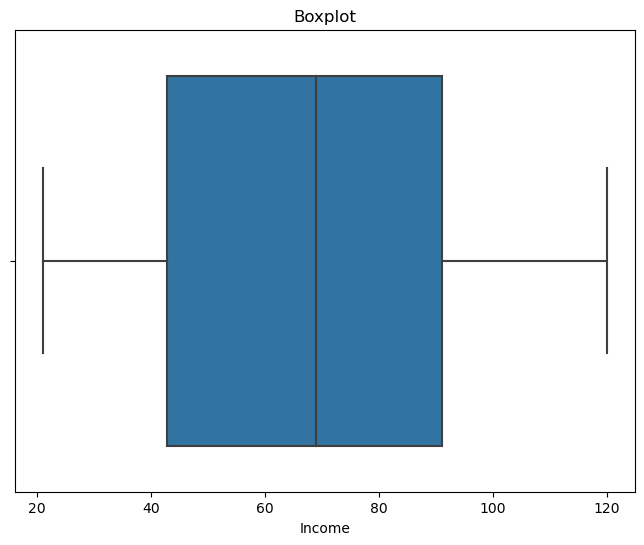

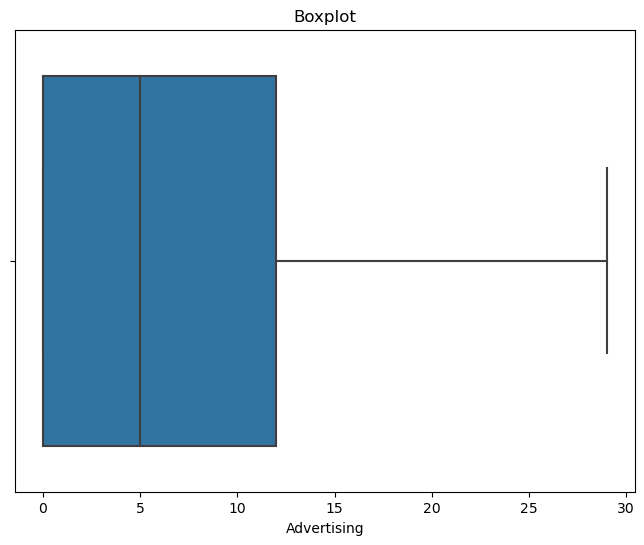

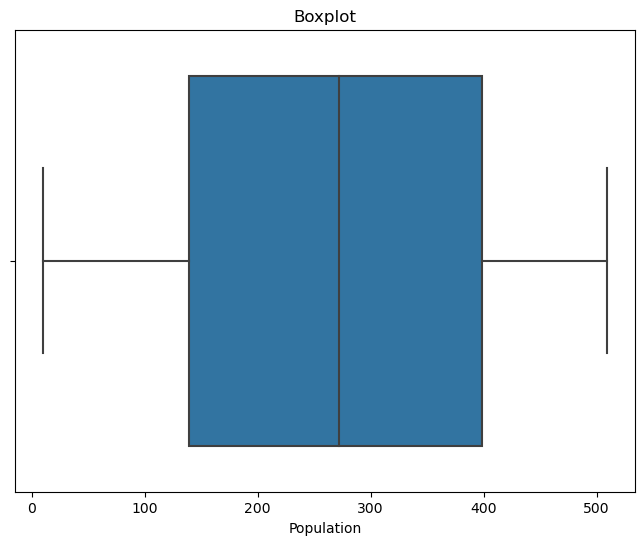

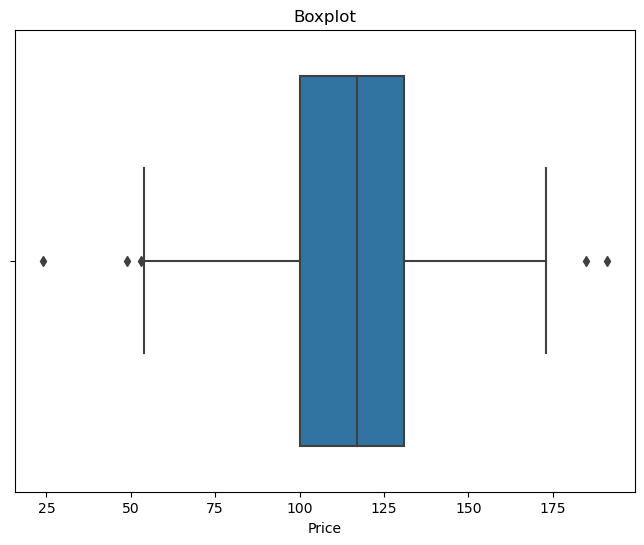

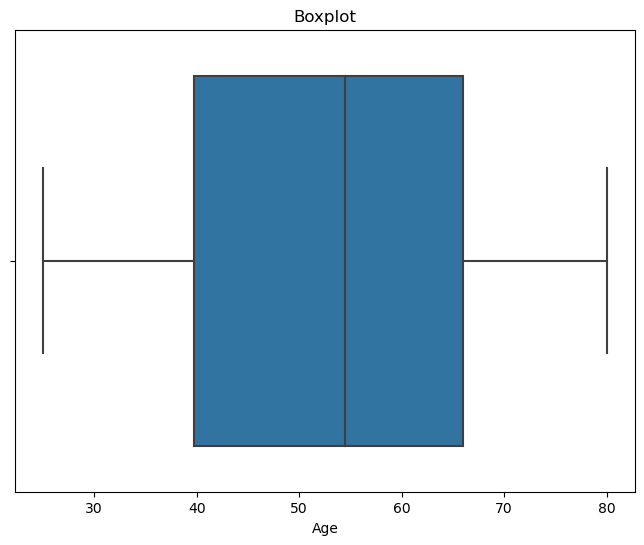

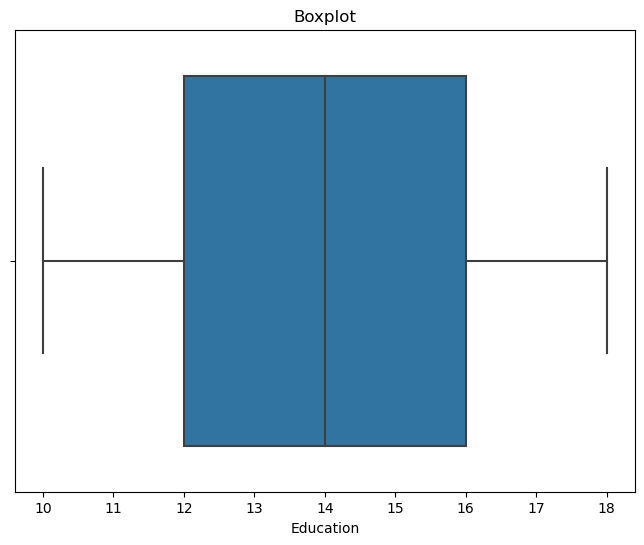

In [522]:
#EDA

data=["Sales","CompPrice","Income","Advertising","Population","Price","Age","Education"]
for column in data:
  plt.figure(figsize=(8,6))
  sns.boxplot(x=df[column])
  plt.title("Boxplot")
  plt.show()

In [523]:
"""removing the ouliers"""
# List of column names with continuous variables
continuous_columns = ["Sales","CompPrice","Income","Advertising","Population","Price","Age","Education"]
# Create a new DataFrame without outliers for each continuous column
data_without_outliers = df.copy()
for columns in continuous_columns:
    Q1 = data_without_outliers[column].quantile(0.25)
    Q3 = data_without_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker_Length = Q1 - 1.5 * IQR
    upper_whisker_Length = Q3 + 1.5 * IQR
    data_without_outliers = data_without_outliers[(data_without_outliers[column] >= lower_whisker_Length) & (data_without_outliers[column]<= upper_whisker_Length)]
# Print the cleaned data without outliers
print(data_without_outliers)#[1363 rows x 9 columns]
df = data_without_outliers

     Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0     9.50        138      73           11         276    120       Bad   42   
1    11.22        111      48           16         260     83      Good   65   
2    10.06        113      35           10         269     80    Medium   59   
3     7.40        117     100            4         466     97    Medium   55   
4     4.15        141      64            3         340    128       Bad   38   
..     ...        ...     ...          ...         ...    ...       ...  ...   
395  12.57        138     108           17         203    128      Good   33   
396   6.14        139      23            3          37    120    Medium   55   
397   7.41        162      26           12         368    159    Medium   40   
398   5.94        100      79            7         284     95       Bad   50   
399   9.71        134      37            0          27    120      Good   49   

     Education Urban   US  
0          

In [525]:
df.isna().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

C:\Users\SHIVA KUMAR\AppData\Local\Temp\ipykernel_14168\2723118421.py:4: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()
C:\Users\SHIVA KUMAR\AppData\Local\Temp\ipykernel_14168\2723118421.py:5: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,124.939850,68.769424,6.651629,264.606516,115.621554,1.305764,53.258145,13.897243,0.706767,0.646617
std,15.337621,27.931394,6.650382,147.487375,23.450571,0.833797,16.169362,2.623237,0.455816,0.478621
min,77.000000,21.000000,0.000000,10.000000,24.000000,0.000000,25.000000,10.000000,0.000000,0.000000
25%,115.000000,43.500000,0.000000,139.000000,100.000000,1.000000,39.500000,12.000000,0.000000,0.000000
50%,125.000000,69.000000,5.000000,272.000000,117.000000,2.000000,54.000000,14.000000,1.000000,1.000000
75%,135.000000,91.000000,12.000000,399.000000,131.000000,2.000000,66.000000,16.000000,1.000000,1.000000
max,175.000000,120.000000,29.000000,509.000000,191.000000,2.000000,80.000000,18.000000,1.000000,1.000000


<Figure size 1000x1200 with 0 Axes>

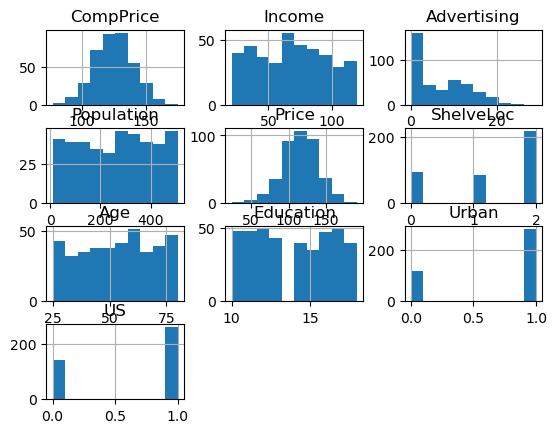

In [543]:
# constructing histograms,calculating skewness and kurtosis values#
plt.figure(figsize=(10,12))
df.hist()
df.skew()
df.kurt()
df.describe()


In [527]:
print(df.isnull().sum())


Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64


In [528]:
df[df.duplicated()].values

array([], shape=(0, 11), dtype=object)

In [529]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [530]:
bins = [0, 10, 15, float('inf')]
labels = ['Low', 'Medium', 'High']
df['Sales_Category'] = pd.cut(df['Sales'], bins=bins, labels=labels)


In [531]:
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sales_Category
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,Low
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,Medium
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,Medium
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,Low
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,Low


In [532]:
# Drop the original 'Sales' column
df.drop('Sales', axis=1, inplace=True)

In [533]:
# Convert categorical variables to numerical using Label Encoding
label_encoder = LabelEncoder()
df['ShelveLoc'] = label_encoder.fit_transform(df['ShelveLoc'])
df['Urban'] = label_encoder.fit_transform(df['Urban'])
df['US'] = label_encoder.fit_transform(df['US'])

In [534]:
df.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sales_Category
0,138,73,11,276,120,0,42,17,1,1,Low
1,111,48,16,260,83,1,65,10,1,1,Medium
2,113,35,10,269,80,2,59,12,1,1,Medium
3,117,100,4,466,97,2,55,14,1,1,Low
4,141,64,3,340,128,0,38,13,1,0,Low


In [535]:
# Example: Remove rows with missing values
df.dropna(inplace=True)


In [536]:
# Split the data into training and testing sets
X = df.drop('Sales_Category', axis=1)
y = df['Sales_Category']
X

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,138,73,11,276,120,0,42,17,1,1
1,111,48,16,260,83,1,65,10,1,1
2,113,35,10,269,80,2,59,12,1,1
3,117,100,4,466,97,2,55,14,1,1
4,141,64,3,340,128,0,38,13,1,0
...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128,1,33,14,1,1
396,139,23,3,37,120,2,55,11,0,1
397,162,26,12,368,159,2,40,18,1,1
398,100,79,7,284,95,0,50,12,1,1


In [537]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [538]:
# Build the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [539]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)


Accuracy: 0.84
Confusion Matrix:
[[62  2]
 [11  5]]
Classification Report:
              precision    recall  f1-score   support

         Low       0.85      0.97      0.91        64
      Medium       0.71      0.31      0.43        16

    accuracy                           0.84        80
   macro avg       0.78      0.64      0.67        80
weighted avg       0.82      0.84      0.81        80



In [540]:
# Display feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('Feature Importances:')
print(feature_importances)

Feature Importances:
Price          0.208120
Advertising    0.132260
ShelveLoc      0.123558
Age            0.120833
CompPrice      0.105263
Income         0.104419
Population     0.104109
Education      0.064103
US             0.023186
Urban          0.014149
dtype: float64


In [545]:
!pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/b3/f8/ee33e36194eb03a76eccf3adac3fba51f0e56fbd20609bb531659d48d3cb/lightgbm-4.1.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.3 MB 991.0 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.3 MB 2.1 MB/s eta 0:00:01
   ------- -------------------------------- 0.3/1.3 MB 2.0 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.3 MB 2.3 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.3 MB 2.5 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.3 MB 2.9 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.3 MB 3.0 MB/s eta 0:00:01
   ----------------------------------- ---- 1.2/1.3 MB 3.2 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.3 MB 3.1 MB/s eta 0:00:01
   -----------------------------------

In [548]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LGBM model
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0,
    'force_col_wise': True  # This may be set based on your data characteristics
}

# Adjust the parameters based on your data and problem

# Make predictions on the test set
y_pred = lgbm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

# Display feature importances
feature_importances = pd.Series(lgbm_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('Feature Importances:')
print(feature_importances)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 319, number of used features: 10
[LightGBM] [Info] Start training from score -5.072044
[LightGBM] [Info] Start training from score -0.216115
[LightGBM] [Info] Start training from score -1.670847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

In [550]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Support Vector Machine model
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# Fit the model to the training data
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{classification_rep}")


Accuracy: 0.825
Confusion Matrix:
[[59  5]
 [ 9  7]]
Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.92      0.89        64
      Medium       0.58      0.44      0.50        16

    accuracy                           0.82        80
   macro avg       0.73      0.68      0.70        80
weighted avg       0.81      0.82      0.82        80

